In [ ]:
# 安装相应的包
!pip install pyecharts
!pip install echarts-countries-pypkg
!pip install echarts-china-provinces-pypkg
!pip install echarts-china-cities-pypkg
!pip install echarts-china-counties-pypkg

In [3]:
import pyecharts
print(pyecharts.__version__)

2.0.6


In [59]:
import pandas as pd
from pyecharts.charts import Map, Geo, BMap
from pyecharts import options as opts 
from pyecharts.globals import ThemeType #引入主题

In [41]:
data = pd.read_csv('分省年度数据.csv', encoding='gb2312')
provinces = list(data["地区"])
gdp_2023 = list(data["2023年"])
pro_gdp_list = [list(z) for z in zip(provinces,gdp_2023)]

In [43]:
print(pro_gdp_list)

[['北京市', 43760.7], ['天津市', 16737.3], ['河北省', 43944.1], ['山西省', 25698.2], ['内蒙古自治区', 24627.0], ['辽宁省', 30209.4], ['吉林省', 13531.2], ['黑龙江省', 15883.9], ['上海市', 47218.7], ['江苏省', 128222.2], ['浙江省', 82553.2], ['安徽省', 47050.6], ['福建省', 54355.1], ['江西省', 32200.1], ['山东省', 92068.7], ['河南省', 59132.4], ['湖北省', 55803.6], ['湖南省', 50012.9], ['广东省', 135673.2], ['广西壮族自治区', 27202.4], ['海南省', 7551.2], ['重庆市', 30145.8], ['四川省', 60132.9], ['贵州省', 20913.3], ['云南省', 30021.1], ['西藏自治区', 2392.7], ['陕西省', 33786.1], ['甘肃省', 11863.8], ['青海省', 3799.1], ['宁夏回族自治区', 5315.0], ['新疆维吾尔自治区', 19125.9]]


In [113]:
map_chart = (
    Map(init_opts=opts.InitOpts(width="1000px", height="600px",theme = ThemeType.DARK))  # 支持切换主题
    .set_global_opts(
        title_opts=opts.TitleOpts(title="2023年中国各省GDP图  单位:亿元"),
        visualmap_opts=opts.VisualMapOpts(
            min_=1000,
            max_=110000,
            range_text=['GDP（亿）范围:', ''],  # 定义颜色区间文本
            is_piecewise=True,  # 设置为分段图例，非连续
            pos_top="center",  # 位置设为中央
            pos_left="left",
            orient="vertical",  # 垂直排列
            split_number=10  # 分成10个颜色区间
        )
    )
    .add("GDP分布", pro_gdp_list, maptype="china")  # 加入GDP数据，使用中国地图
    .render("GDP_Map_2023.html")  # 生成文件名修改为GDP_Map_2019.html
)



In [55]:
pro_gdp_list = [['北京市', 43760.7], ['天津市', 16737.3], ['河北省', 43944.1], ['山西省', 25698.2], ['内蒙古', 24627.0], ['辽宁省', 30209.4], ['吉林省', 13531.2], ['黑龙江省', 15883.9], ['上海市', 47218.7], ['江苏省', 128222.2], ['浙江省', 82553.2], ['安徽省', 47050.6], ['福建省', 54355.1], ['江西省', 32200.1], ['山东省', 92068.7], ['河南省', 59132.4], ['湖北省', 55803.6], ['湖南省', 50012.9], ['广东省', 135673.2], ['广西', 27202.4], ['海南省', 7551.2], ['重庆市', 30145.8], ['四川省', 60132.9], ['贵州省', 20913.3], ['云南省', 30021.1], ['西藏', 2392.7], ['陕西省', 33786.1], ['甘肃省', 11863.8], ['青海省', 3799.1], ['宁夏', 5315.0], ['新疆', 19125.9]]

In [57]:
from pyecharts.globals import ChartType

# 创建Geo对象并配置地图类型为中国地图
geo_chart = (
    Geo()
    .add_schema(maptype="china")  # 指定地图为中国地图
    .add(
        series_name="GDP",  # 设置系列名称
        data_pair=pro_gdp_list,  # 数据来源，可以是[('省份', 值), ...]的形式
        symbol_size=10,  # 点的大小
        large_threshold=110000,  # 数据阈值，大于该值时优化渲染
        type_=ChartType.EFFECT_SCATTER  # 使用涟漪效果的散点图
    )
    .set_series_opts(
        label_opts=opts.LabelOpts(is_show=False)  # 隐藏数据标签
    )
    .set_global_opts(
        visualmap_opts=opts.VisualMapOpts(max_=110000),  # 设置视觉映射最大值
        title_opts=opts.TitleOpts(title="2023年各省GDP散点涟漪效果")  # 设置标题
    )
    .render("GDP_Geo_2023.html")  # 生成HTML文件并保存
)

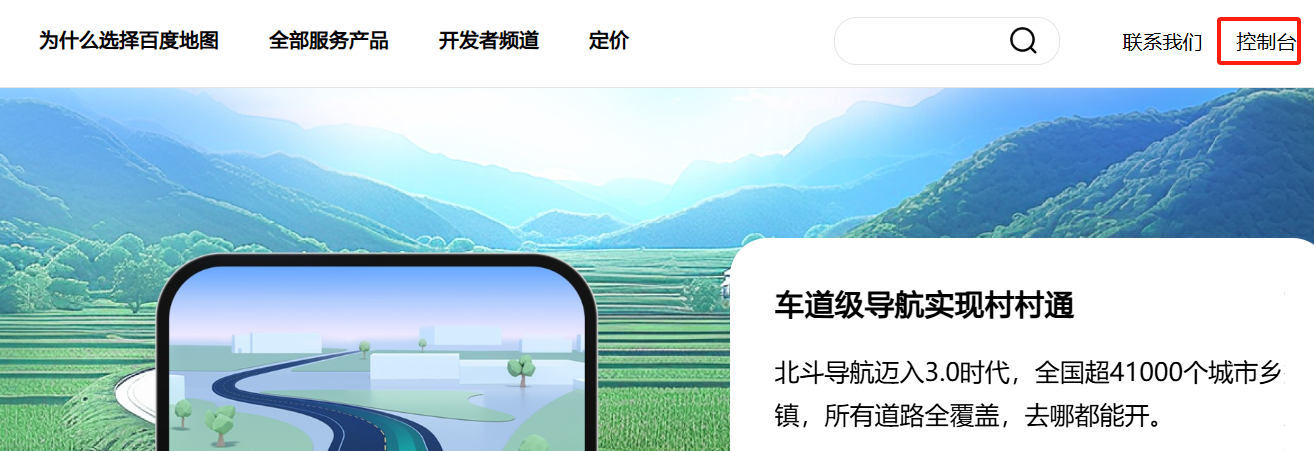

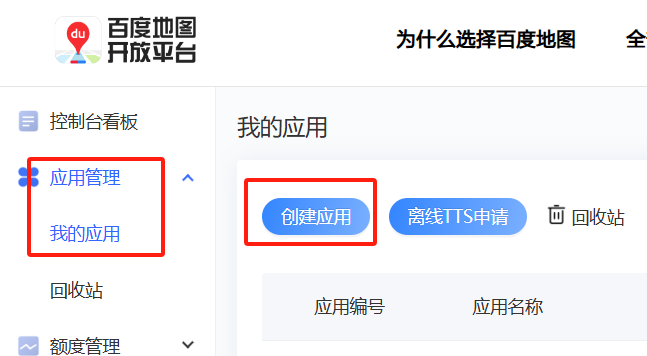

In [67]:
# 创建一个百度地图实例，指定画布的宽度和高度
map_chart = (
    BMap(init_opts=opts.InitOpts(width="1000px", height="600px"))  # 设置地图宽度为1000像素，高度为600像素
    .add_schema(baidu_ak="你的AK", center=[120.13066322374, 30.240018034923])  # 添加地图的中心点和百度地图的AK
    .add(
        "GDP分布",  # 图例名称为GDP分布
        pro_gdp_list,  # 数据源，列表类型
        type_="heatmap",  # 使用热力图展示数据，其他可选值包括散点图和涟漪图
        label_opts=opts.LabelOpts(formatter="{b}")  # 显示标签，{b}表示显示对应的数据名称
    )
    .set_global_opts(
        title_opts=opts.TitleOpts(title="2023年中国各省GDP热力图"),  # 设置地图的标题
        visualmap_opts=opts.VisualMapOpts(max_=110000)  # 设置视觉映射，最大值为110000
    )
    .render("gdp_heatmap.html")  # 将图表渲染成HTML文件
)

In [105]:
import pandas as pd
import folium
from folium import plugins

# 读取CSV文件，包含景区的经纬度信息
scenic_data = pd.read_csv('scenic_spot.csv', encoding='utf-8')

# 创建Folium地图实例，设置初始视角的中心点与缩放级别
# 此处使用了Stamen Terrain作为底图，显示具有地形效果的地图，但是好像这个底图不显示
# map_view = folium.Map(location=[23.122373, 113.268027], zoom_start=10, control_scale=True, tiles='Stamen Terrain', attr='&copy; <a href="http://ditu.amap.com/">百度地图</a>')
tiles = 'https://wprd01.is.autonavi.com/appmaptile?x={x}&y={y}&z={z}&lang=zh_cn&size=1&scl=1&style=10'  # style可选[6, 7]等

# 可以尝试不同的地图类型，如Mapbox Bright、黑白风格底图等
# map_view = folium.Map(location=[23.122373, 113.268027], zoom_start=10, control_scale=True, tiles='OpenStreetMap', attr='&copy; <a href="http://ditu.amap.com/">百度地图</a>')
map_view = folium.Map(location=[23.122373, 113.268027], zoom_start=10, control_scale=True, tiles=tiles, attr='&copy; <a href="http://ditu.amap.com/">百度地图</a>')

# 添加一个地图标记，标记位置为中心点，并使用绿色的云朵图标
folium.Marker(
    location=[23.122373, 113.268027],
    popup='<i>Custom Marker</i>',  # 点击标记显示弹出文本
    icon=folium.Icon(icon='cloud', color='green')  # 使用云朵形状的绿色图标
).add_to(map_view)

# 将热力图添加到地图中，通过遍历数据中的每一行提取经纬度
map_view.add_child(
    plugins.HeatMap(
        [[row["lat"], row["lon"]] for _, row in scenic_data.iterrows()]  # 提取每一行的纬度和经度
    )
)

# 将生成的地图保存为HTML文件
map_view.save("scenic_Mapbox_style_10.html")


In [111]:
# 创建Folium地图实例，设置初始中心点和缩放级别，使用Stamen Toner底图
plotmap1 = folium.Map(location=[23.122373, 113.268027], zoom_start=10, control_scale=True, tiles='OpenStreetMap', attr='&copy; <a href="http://ditu.amap.com/">百度地图</a>')

# 添加一个标记，标记位置为中心点，并显示自定义弹出框
folium.Marker(
    [23.122373, 113.268027],
    popup='<p style="color: green">我是J哥</p>',
    icon=folium.Icon(icon='cloud', color='green')
).add_to(plotmap1)

# 创建一个聚合散点图层，并将景区经纬度添加进去
marker_cluster = plugins.MarkerCluster().add_to(plotmap1)

# 遍历CSV文件中的每一行，并将每个景区的经纬度添加为标记
for _, row in scenic_data.iterrows():
    folium.Marker(
        location=[row["lat"], row["lon"]],
        popup=row.get("name", "Unknown Location")  # 弹出窗口显示景区名称，若没有名称则显示"Unknown Location"
    ).add_to(marker_cluster)

# 保存生成的地图为HTML文件
plotmap1.save('folium_map2.html')
